# Decoded Plots

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pathlib import Path


csv_path = Path("../../output/decoded.csv")
df = pd.read_csv(csv_path)

## Frequency plots with fixed data volume and noise volume

In [2]:
from pandas import DataFrame


def get_configs(
    df: DataFrame, outer_label: str, inner_label: str
) -> list[list[DataFrame]]:
    unique_outer = df[outer_label].unique()
    unique_inner = df[inner_label].unique()
    all_configs: list[list[DataFrame]] = []
    for outer_value in unique_outer:
        fixed_outer: list[DataFrame] = []
        for inner_value in unique_inner:
            fixed_outer.append(
                df[(df[inner_label] == inner_value) & (df[outer_label] == outer_value)]
            )
        all_configs.append(fixed_outer)
    return all_configs


def format_float_label(value: float, decimals: int = 2) -> str:
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


def plot_single_config(
    ax,
    config: list[DataFrame],
    x_col: str,
    y_col: str,
    series_col: str,
    series_label_prefix: str = "Series",
    marker: str = "o",
    linewidth: float = 2,
    markersize: float = 6,
    label_decimals: int = 2,
    sort_by: str | None = None,
) -> None:
    effective_sort_col = sort_by if sort_by is not None else x_col

    for filtered_df in config:
        if filtered_df.empty:
            continue

        sorted_df = filtered_df.sort_values(effective_sort_col)
        series_value = sorted_df[series_col].iloc[0]
        series_label = format_float_label(series_value, decimals=label_decimals)

        ax.plot(
            sorted_df[x_col],
            sorted_df[y_col],
            marker=marker,
            label=f"{series_label_prefix}: {series_label}",
            linewidth=linewidth,
            markersize=markersize,
        )


def plot_configs(
    df: DataFrame,
    configs: list[list[DataFrame]],
    outer_col: str,
    x_col: str,
    y_col: str,
    series_col: str,
    title_template: str,
    x_label: str,
    y_label: str,
    y_limits: tuple[float, float] | None = (0, 1),
    series_label_prefix: str = "Series",
    marker: str = "o",
    linewidth: float = 2,
    markersize: float = 6,
    label_decimals: int = 2,
) -> None:
    outer_values = df[outer_col].unique()

    for outer_idx, config in enumerate(configs):
        fig, ax = plt.subplots(figsize=(12, 6))

        plot_single_config(
            ax=ax,
            config=config,
            x_col=x_col,
            y_col=y_col,
            series_col=series_col,
            series_label_prefix=series_label_prefix,
            marker=marker,
            linewidth=linewidth,
            markersize=markersize,
            label_decimals=label_decimals,
            sort_by=x_col,
        )

        ax.set_xlabel(x_label, fontsize=12)
        ax.set_ylabel(y_label, fontsize=12)
        if y_limits is not None:
            ax.set_ylim(*y_limits)

        outer_value = outer_values[outer_idx]
        outer_value_label = format_float_label(outer_value, decimals=label_decimals)
        ax.set_title(title_template.format(outer_value=outer_value_label), fontsize=14)
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


def plot_correctness_vs_frequency(df: DataFrame) -> None:
    configs = get_configs(
        df,
        "volume_gain_data",
        "volume_noise",
    )
    plot_configs(
        df=df,
        configs=configs,
        outer_col="volume_gain_data",
        x_col="frequency",
        y_col="correctness",
        series_col="volume_noise",
        title_template="Correctness vs Frequency (data volume={outer_value})",
        x_label="Frequency",
        y_label="Correctness",
        y_limits=(0, 1),
        series_label_prefix="Noise",
        marker="o",
        linewidth=2,
        markersize=6,
        label_decimals=2,
    )


def plot_correctness_vs_volume_noise(df: DataFrame) -> None:
    configs = get_configs(
        df,
        "volume_gain_data",
        "frequency",
    )
    plot_configs(
        df=df,
        configs=configs,
        outer_col="volume_gain_data",
        x_col="volume_noise",
        y_col="correctness",
        series_col="frequency",
        title_template="Correctness vs Noise (data volume={outer_value})",
        x_label="Volume Noise",
        y_label="Correctness",
        y_limits=(0, 1),
        series_label_prefix="Frequency",
        marker="o",
        linewidth=2,
        markersize=6,
        label_decimals=2,
    )


def plot_correctness_vs_volume_gain_data(df: DataFrame) -> None:
    configs = get_configs(
        df,
        "volume_noise",
        "frequency",
    )
    plot_configs(
        df=df,
        configs=configs,
        outer_col="volume_noise",
        x_col="volume_gain_data",
        y_col="correctness",
        series_col="frequency",
        title_template="Correctness vs Data Volume (noise={outer_value})",
        x_label="Volume Gain Data",
        y_label="Correctness",
        y_limits=(0, 1),
        series_label_prefix="Frequency",
        marker="o",
        linewidth=2,
        markersize=6,
        label_decimals=2,
    )

## Correctness vs Frequency

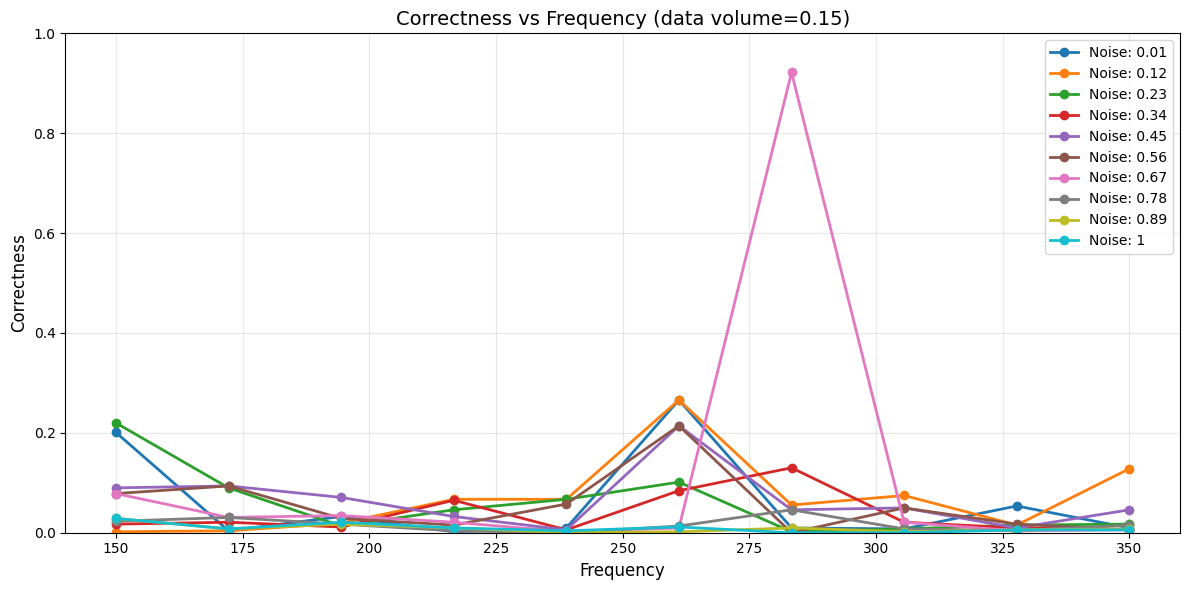

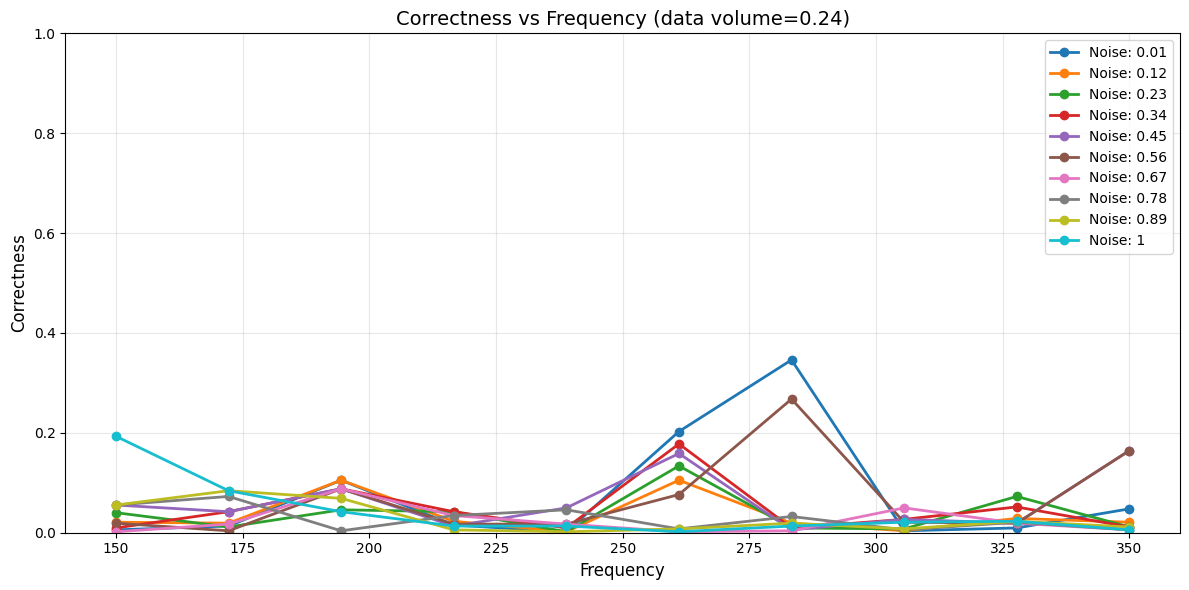

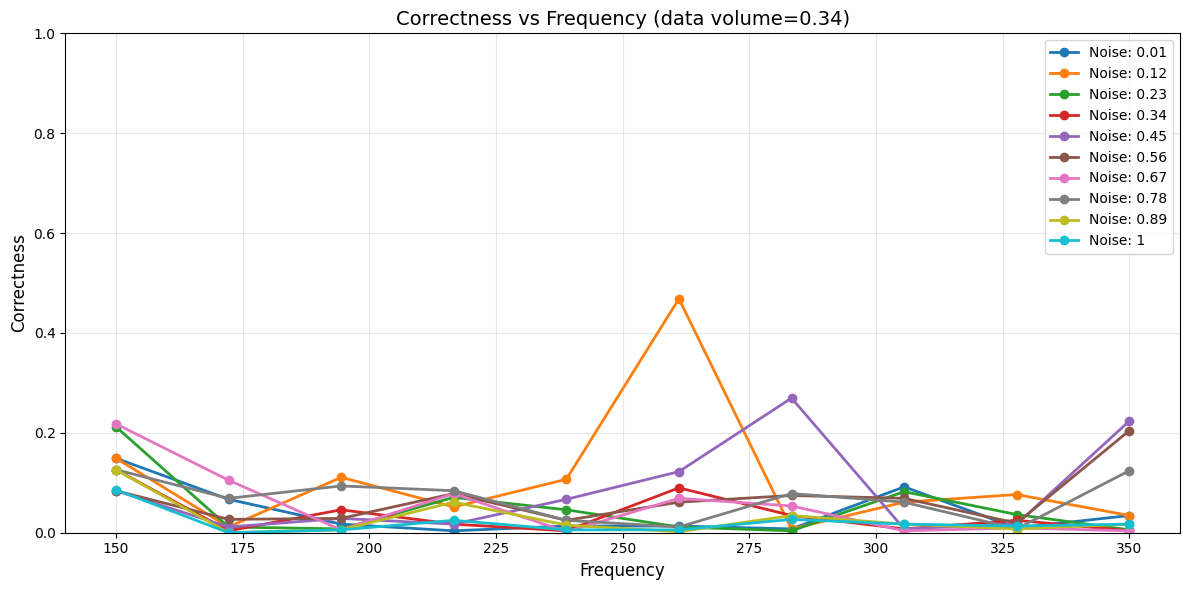

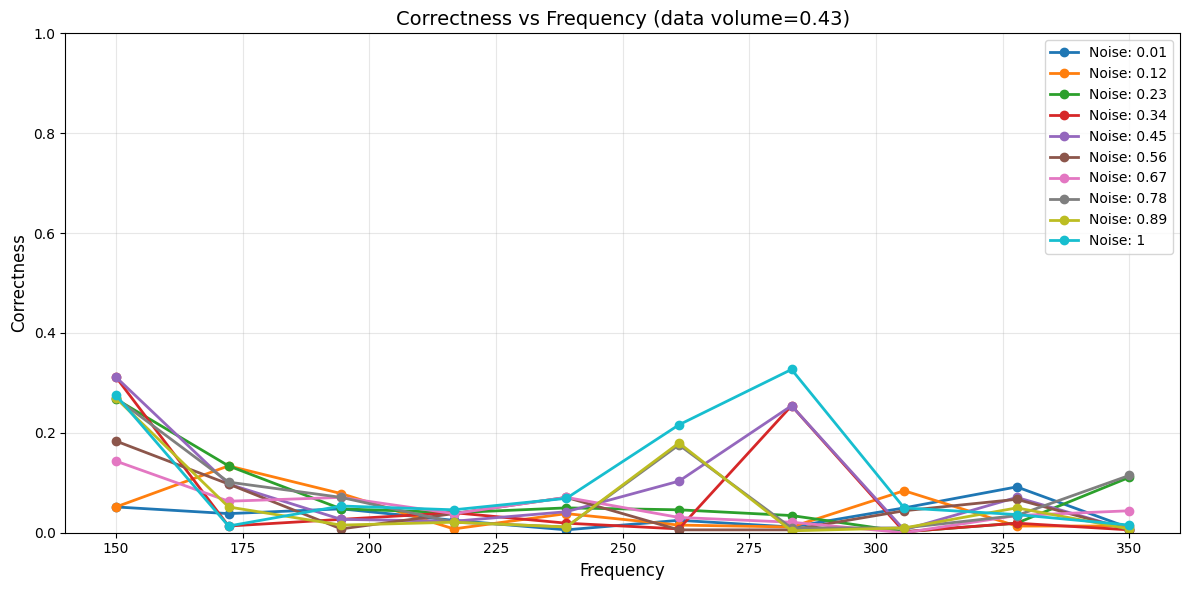

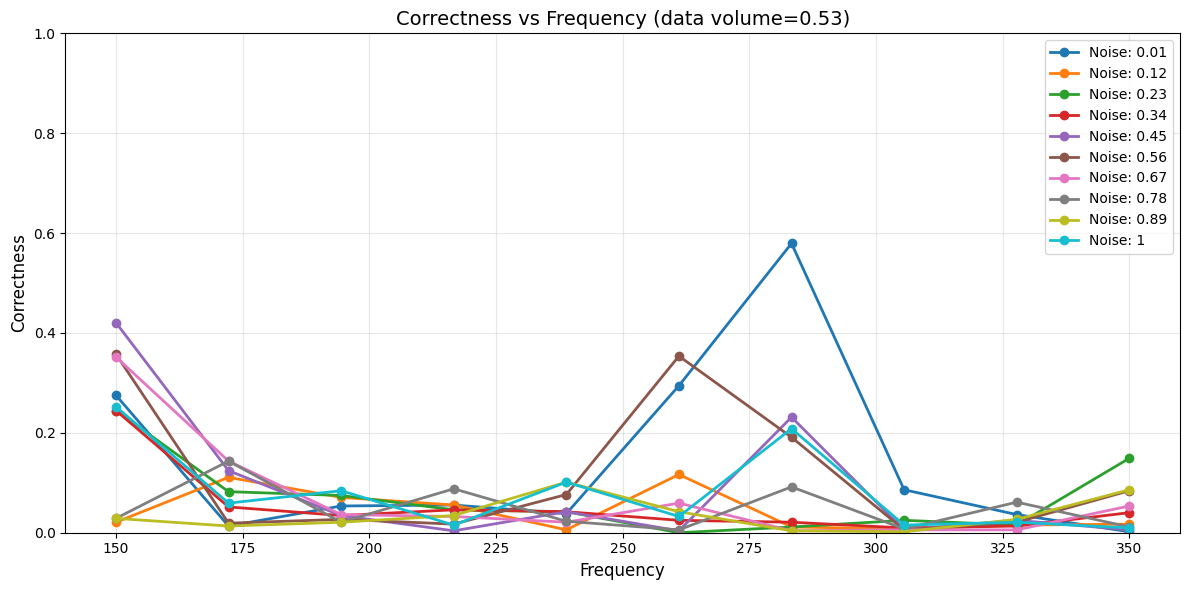

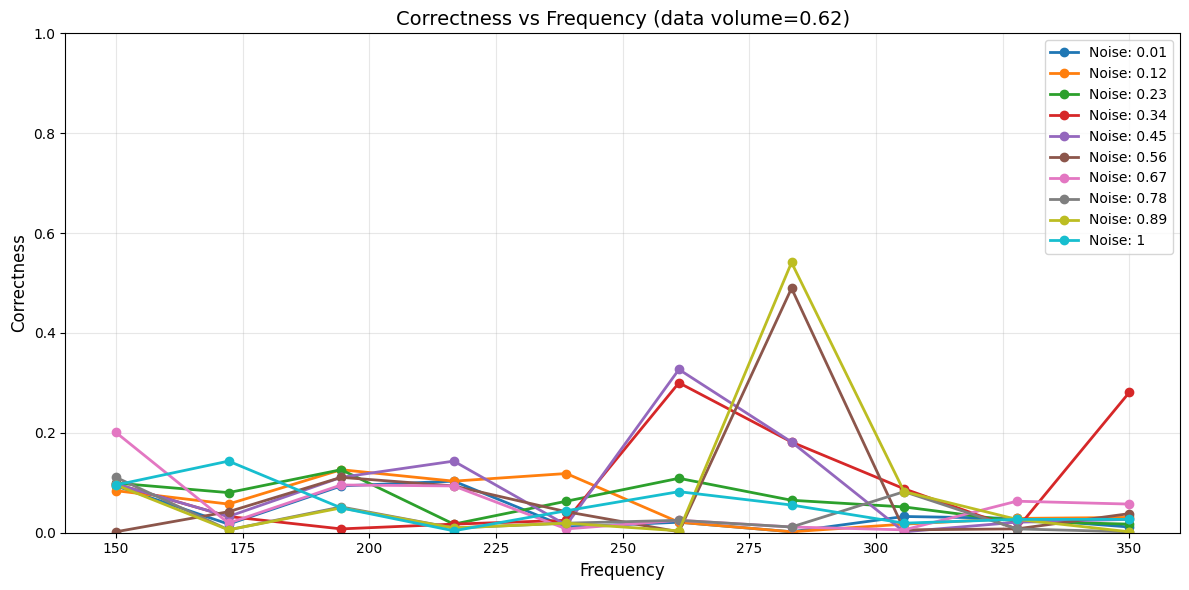

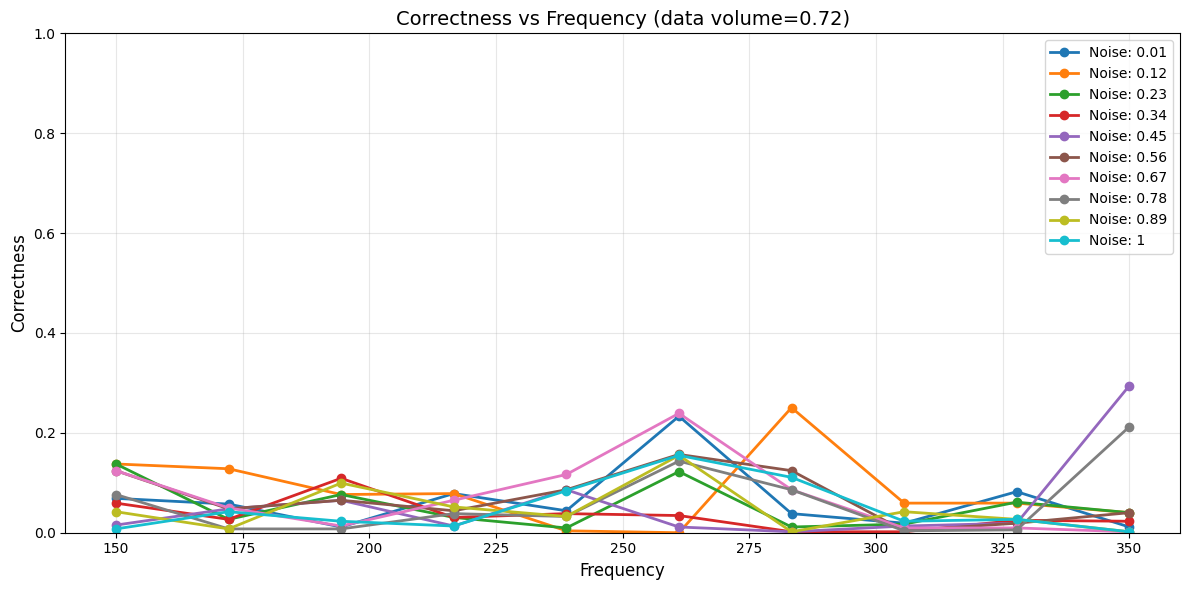

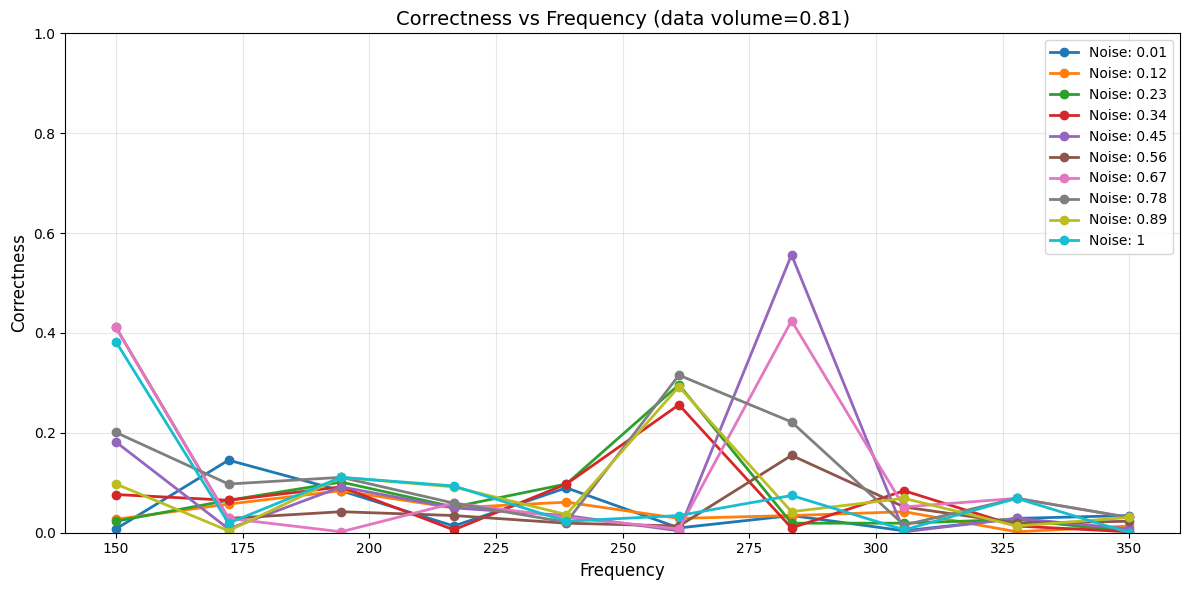

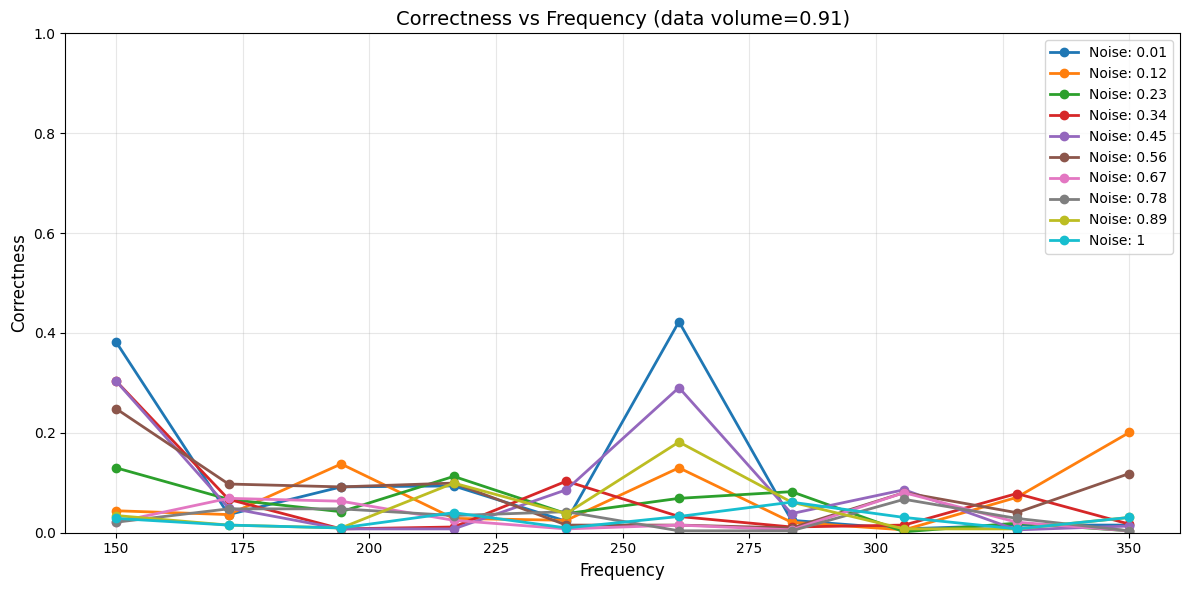

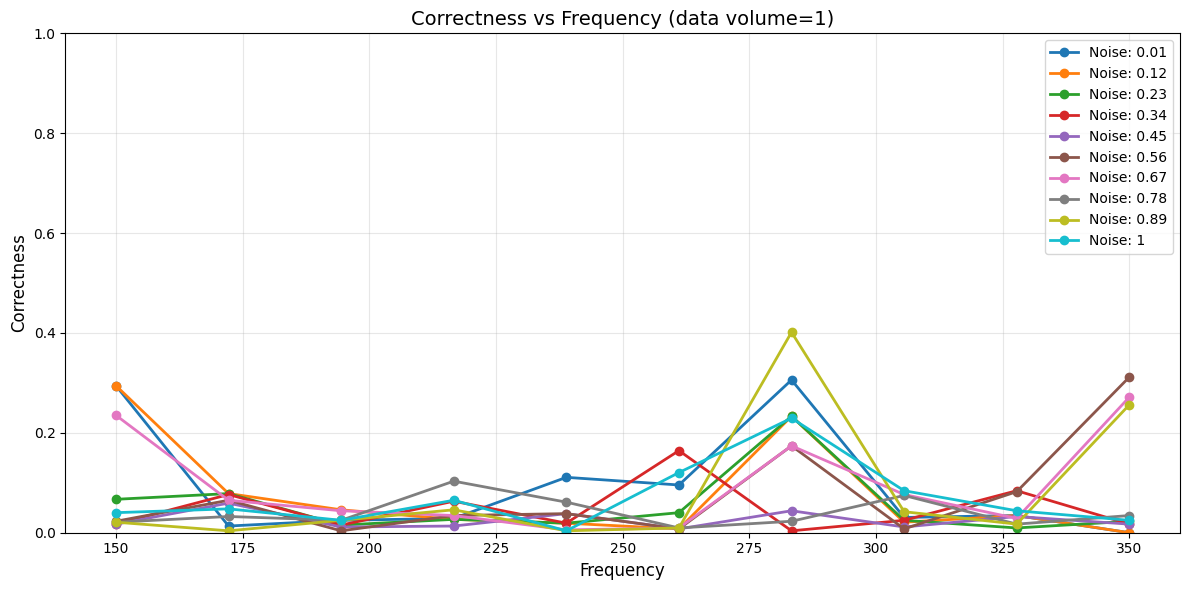

In [3]:
plot_correctness_vs_frequency(df)

## Correctness vs Noise

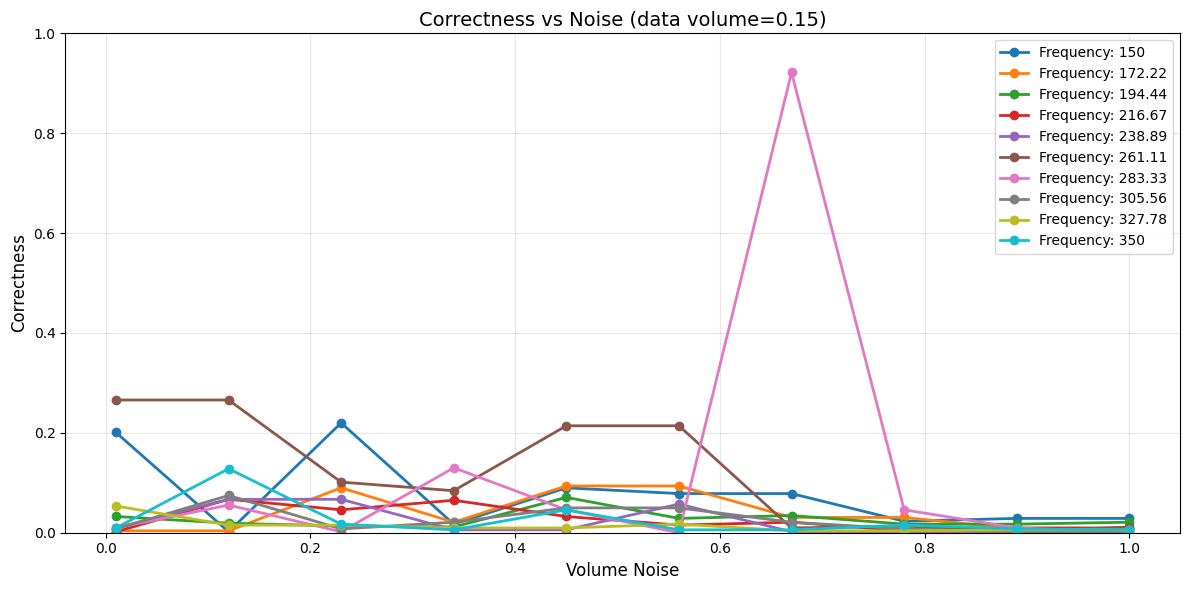

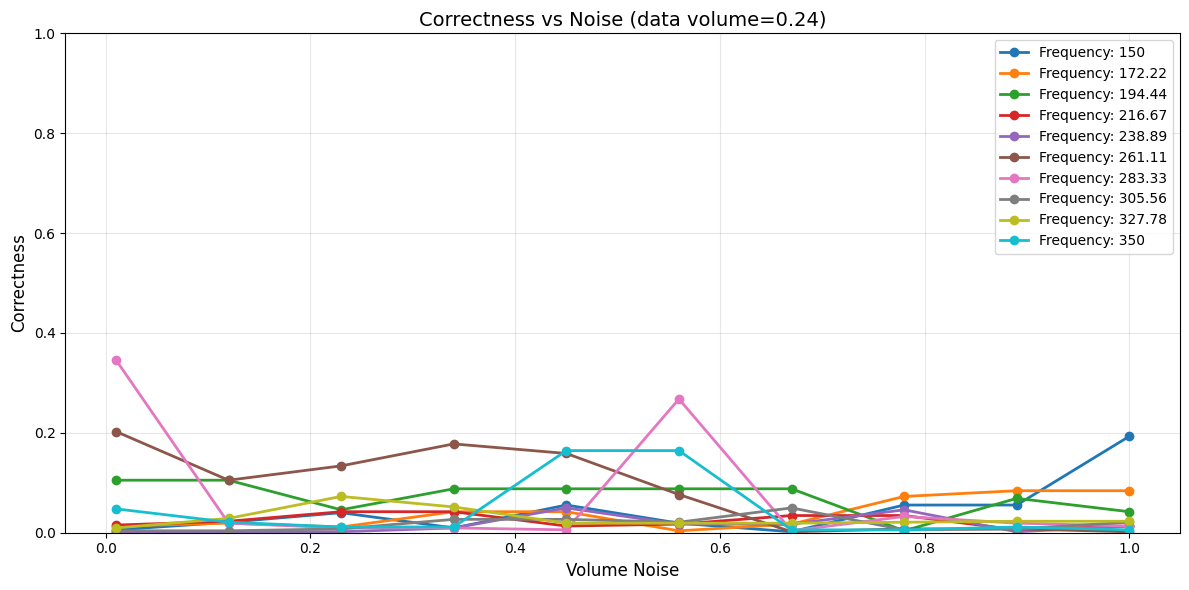

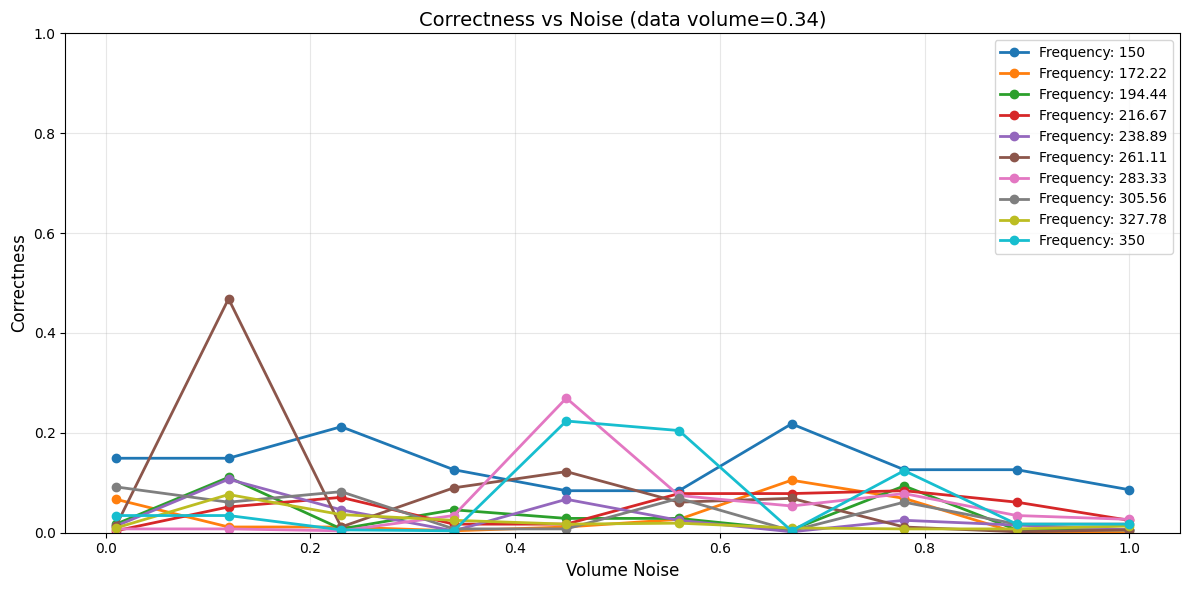

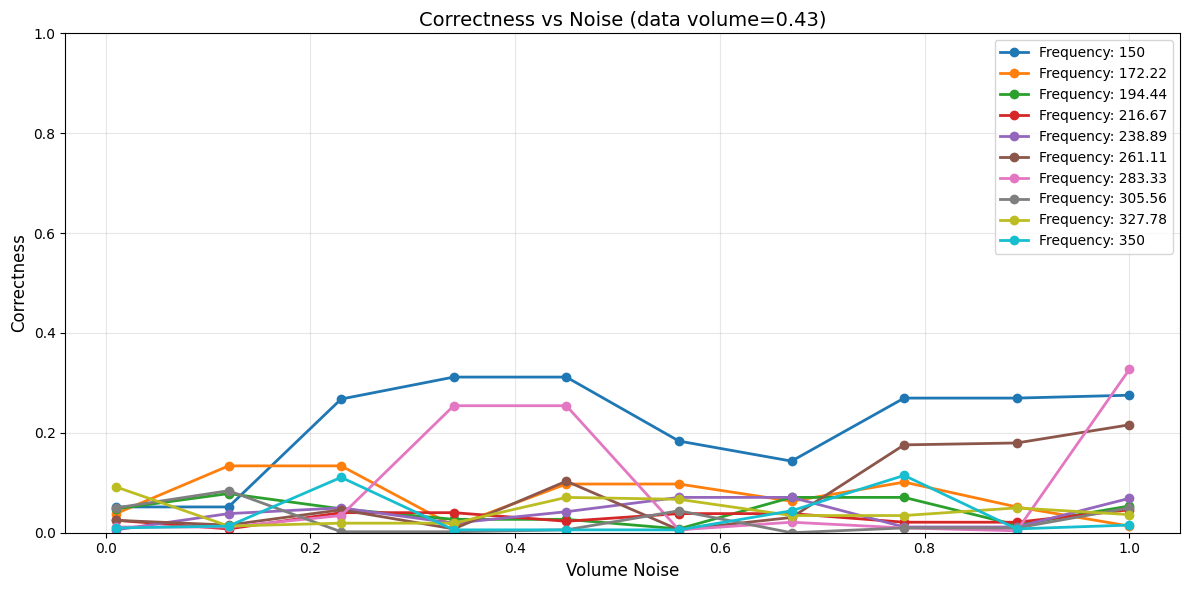

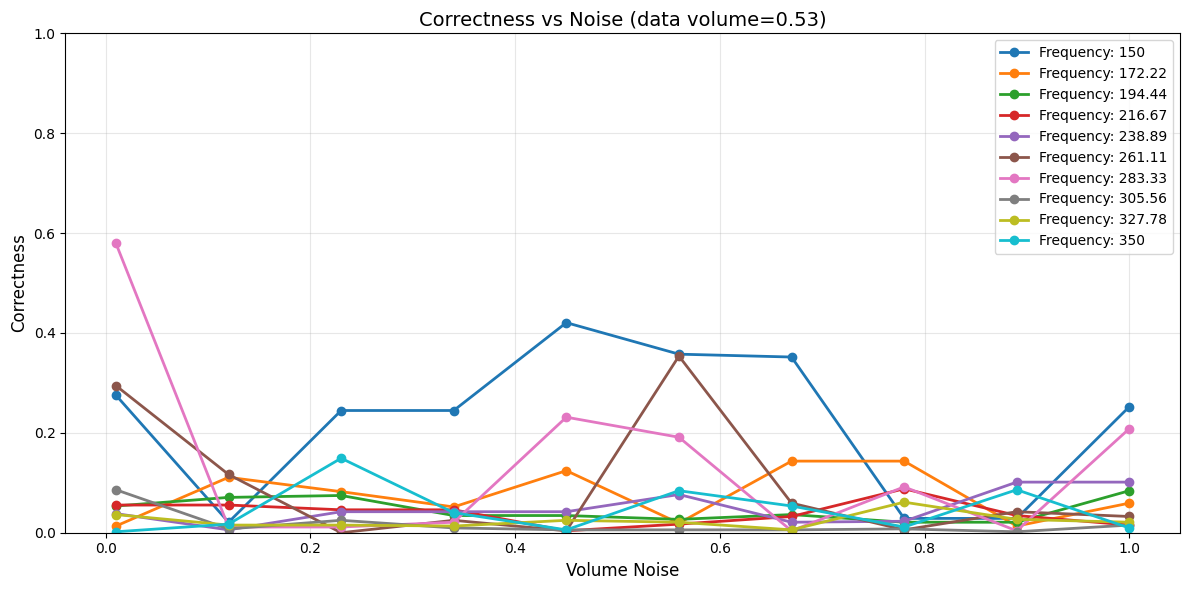

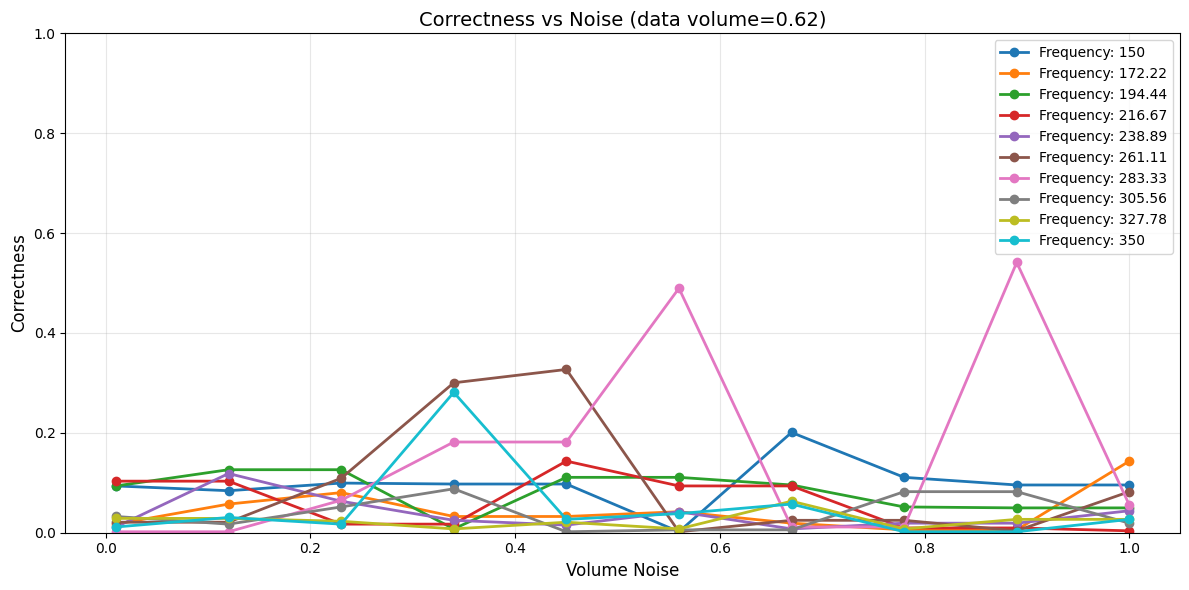

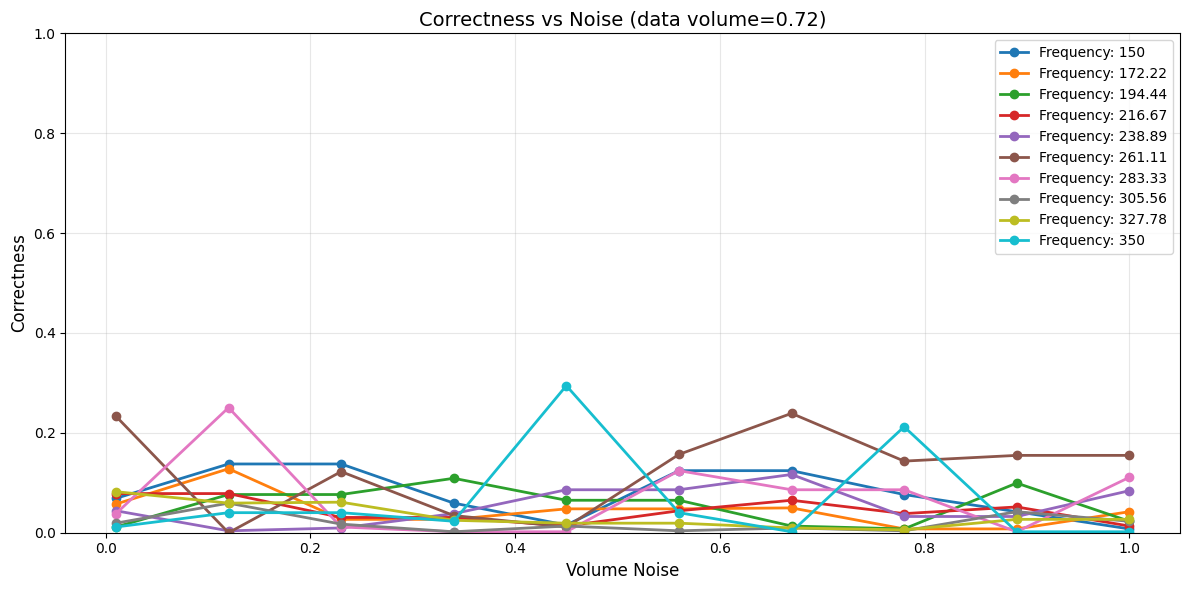

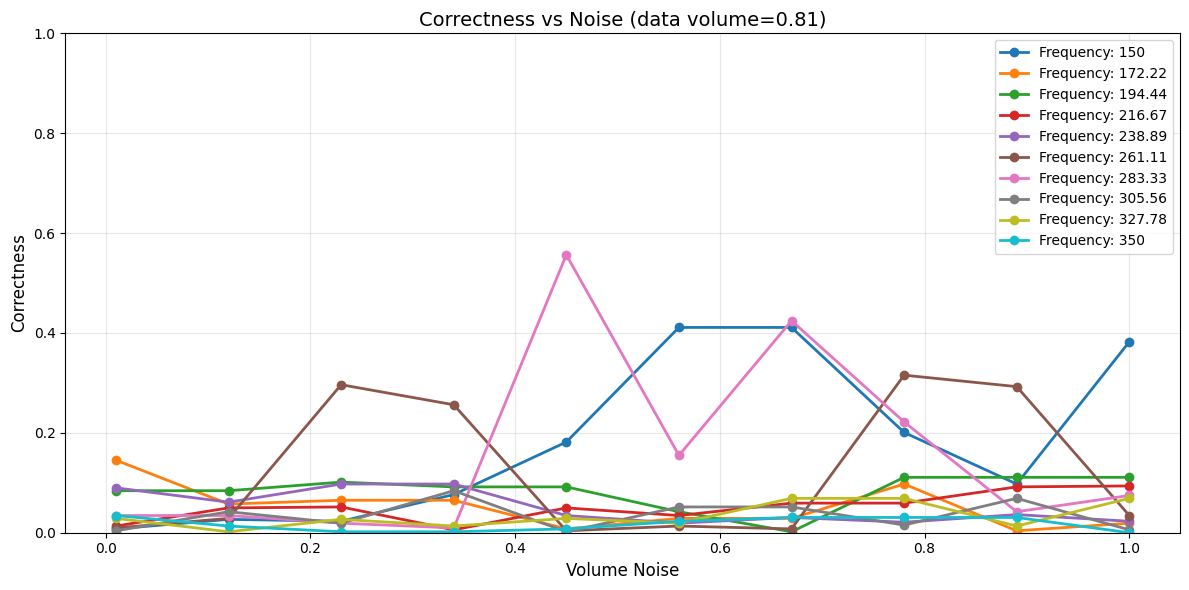

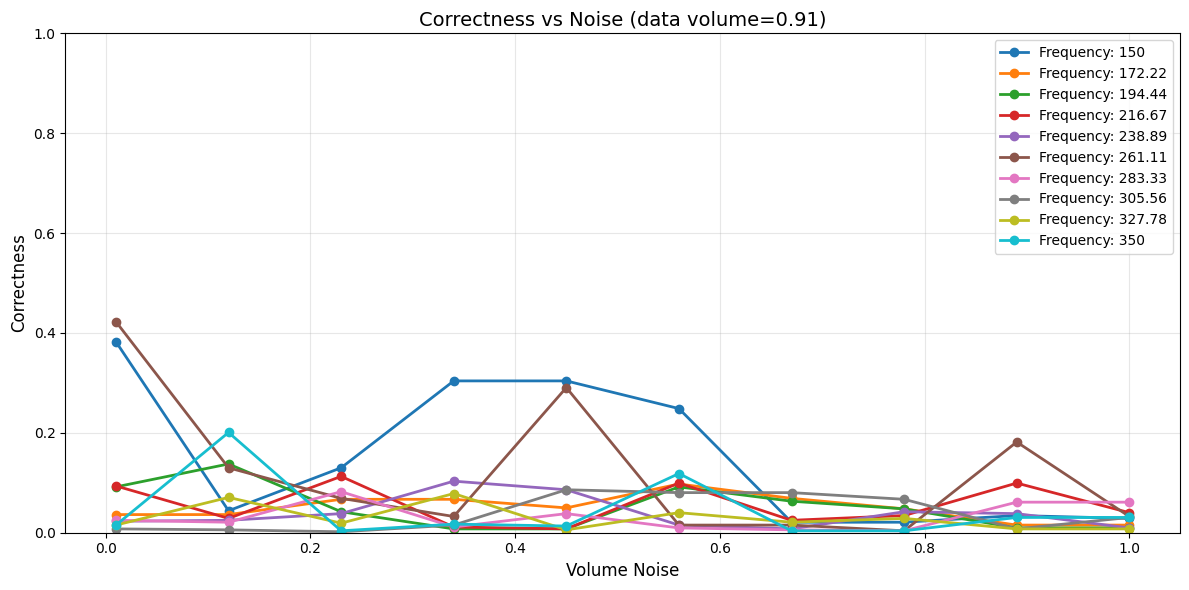

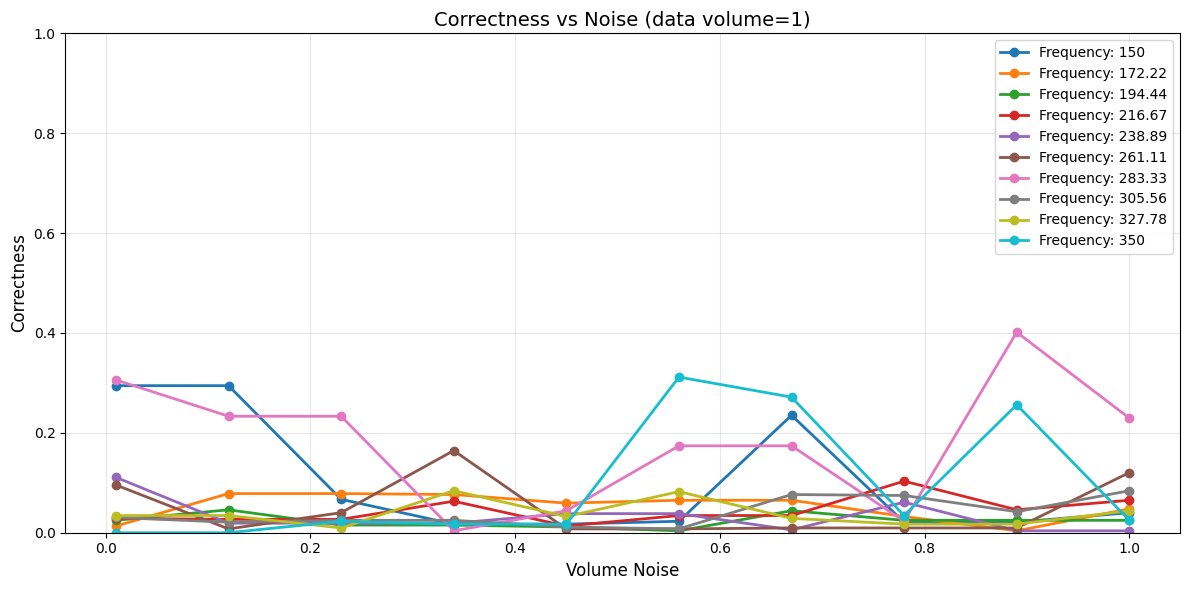

In [4]:
plot_correctness_vs_volume_noise(df)

## Correctness vs Data Audio Volume

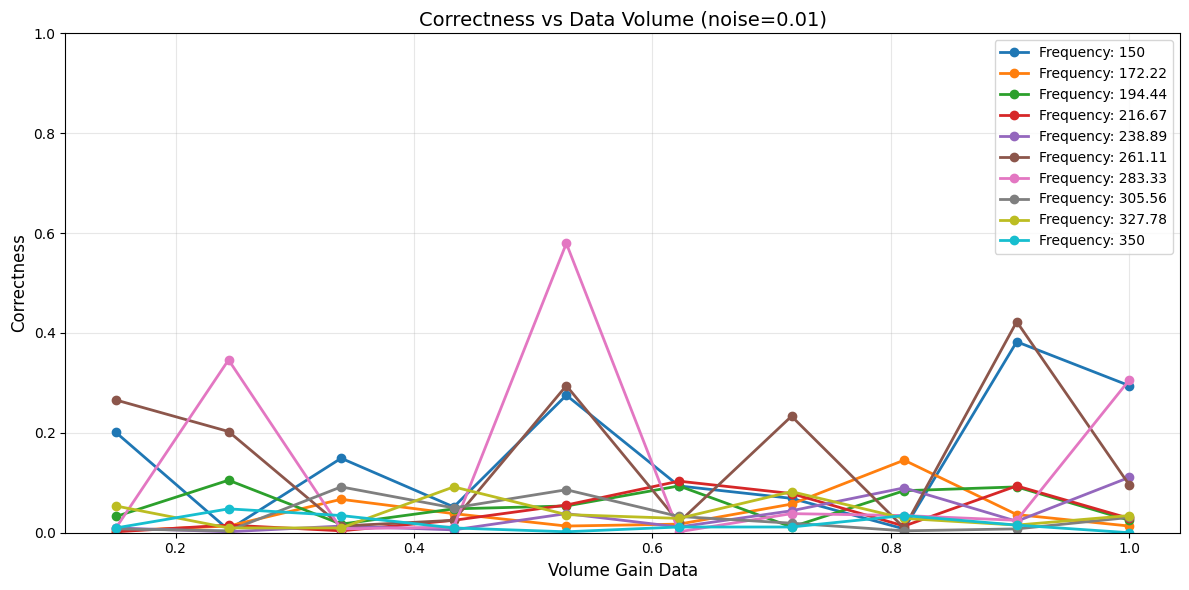

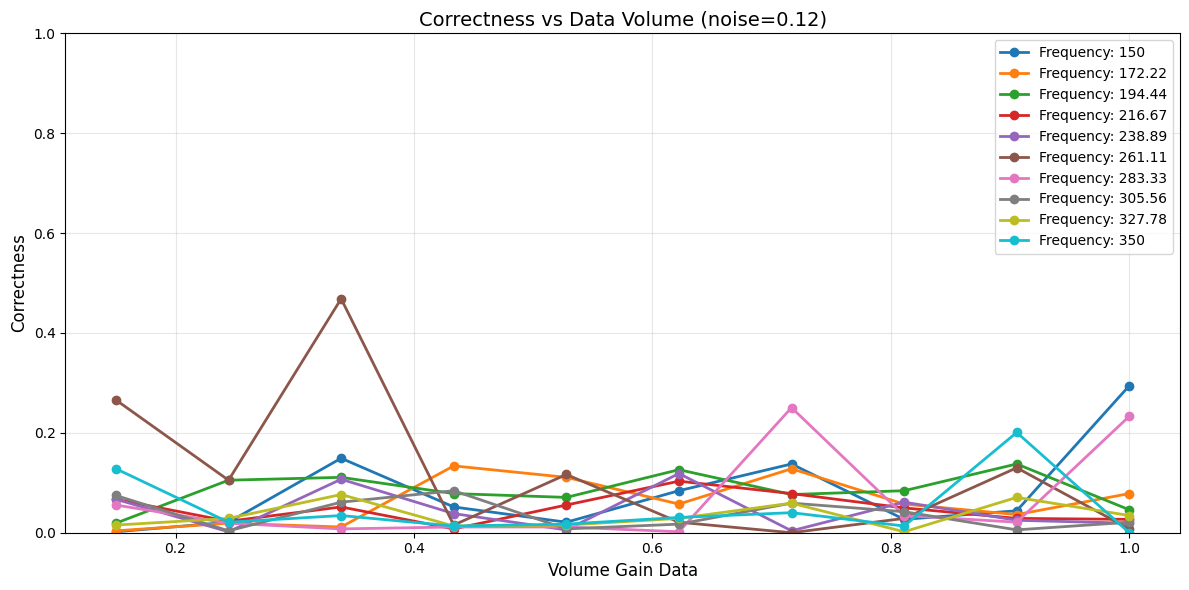

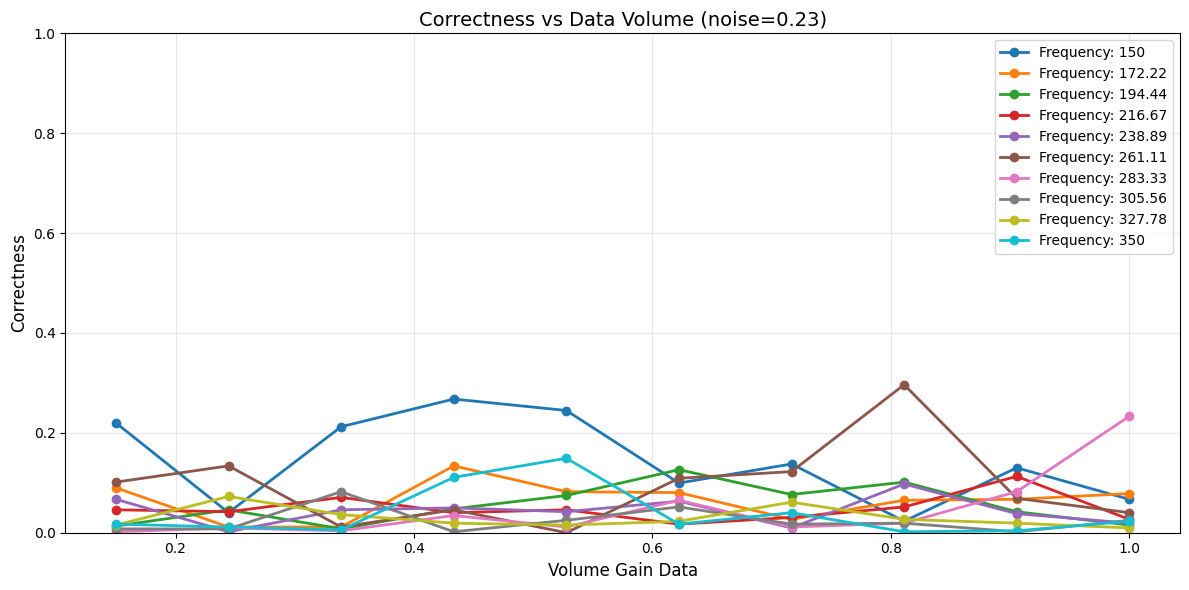

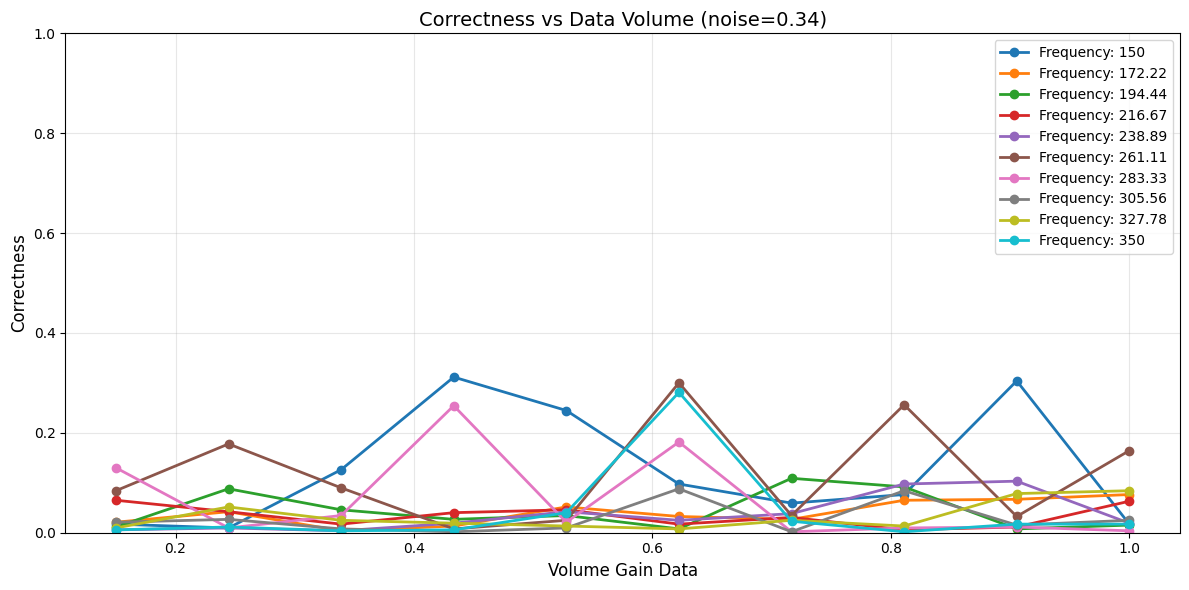

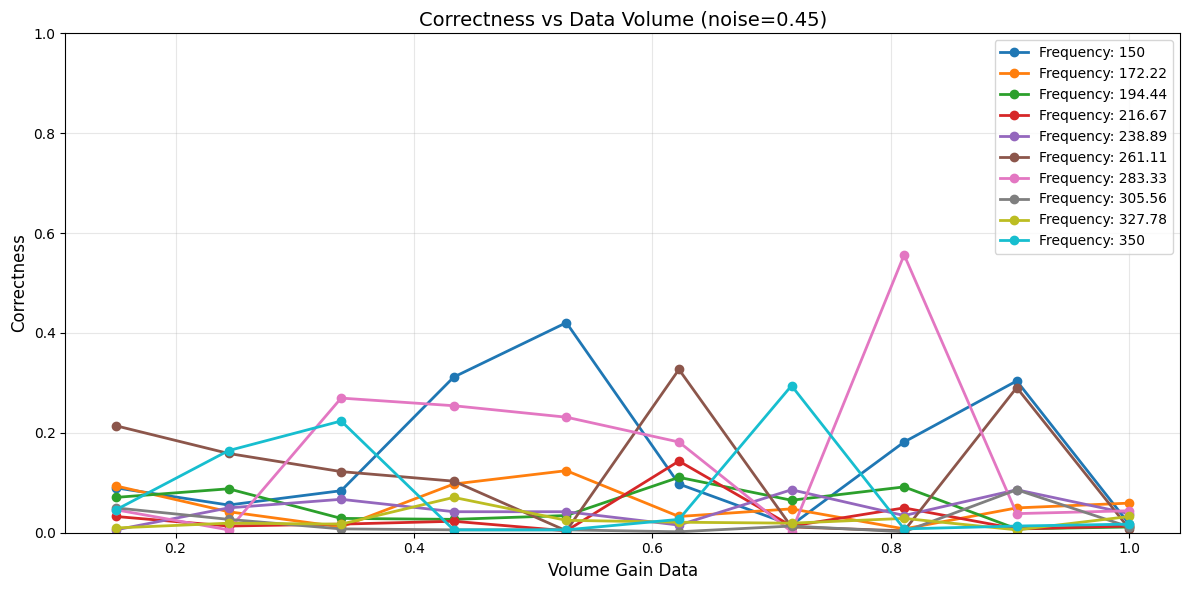

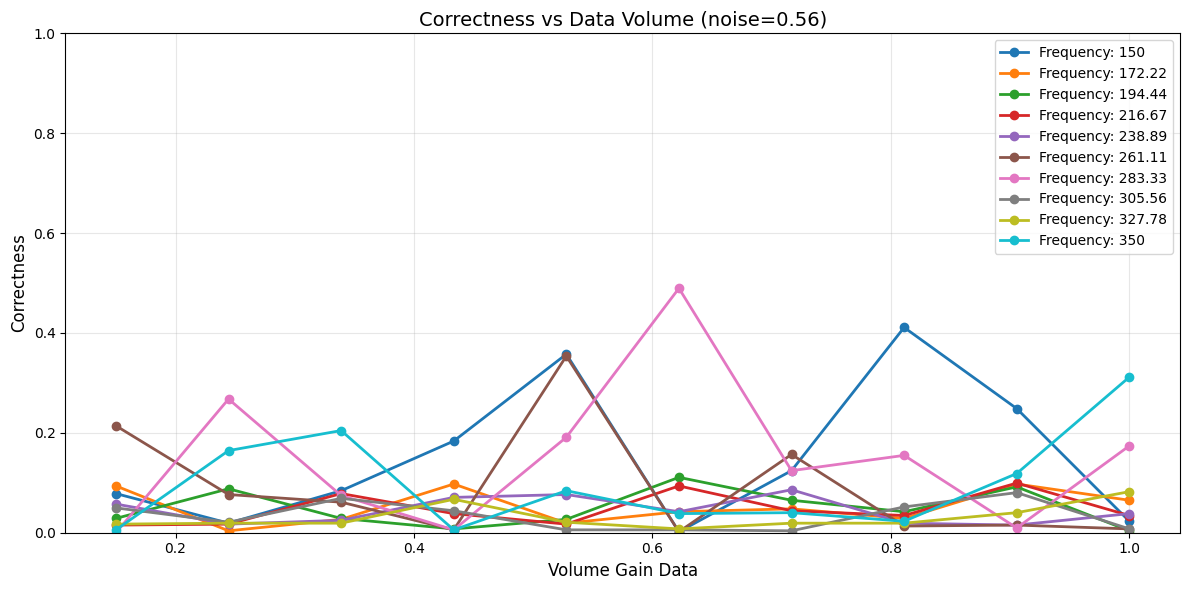

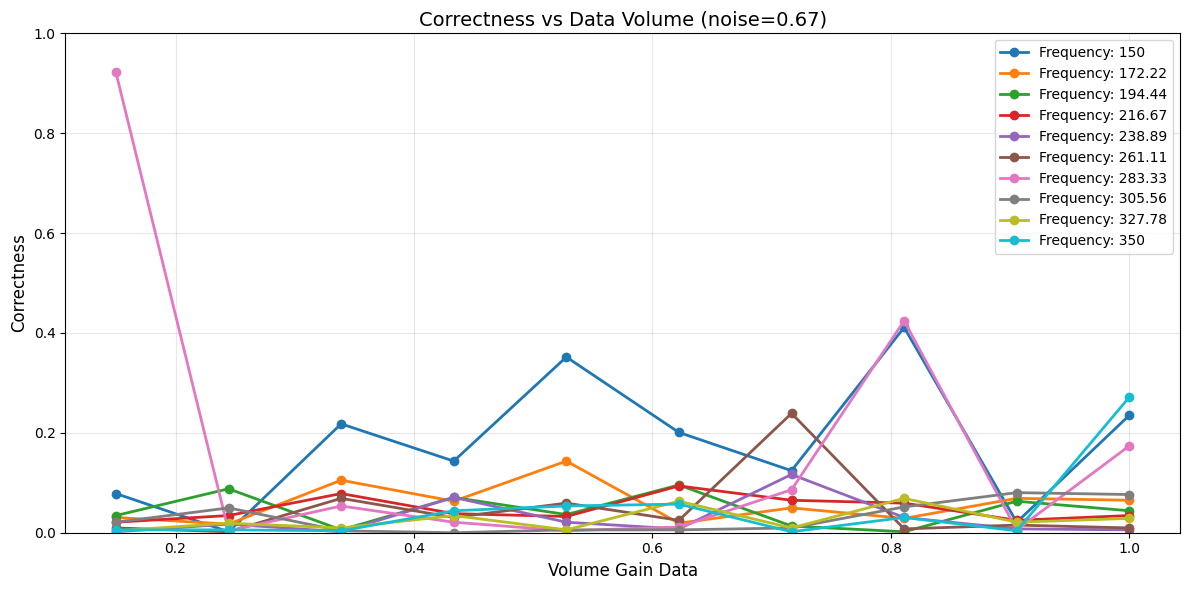

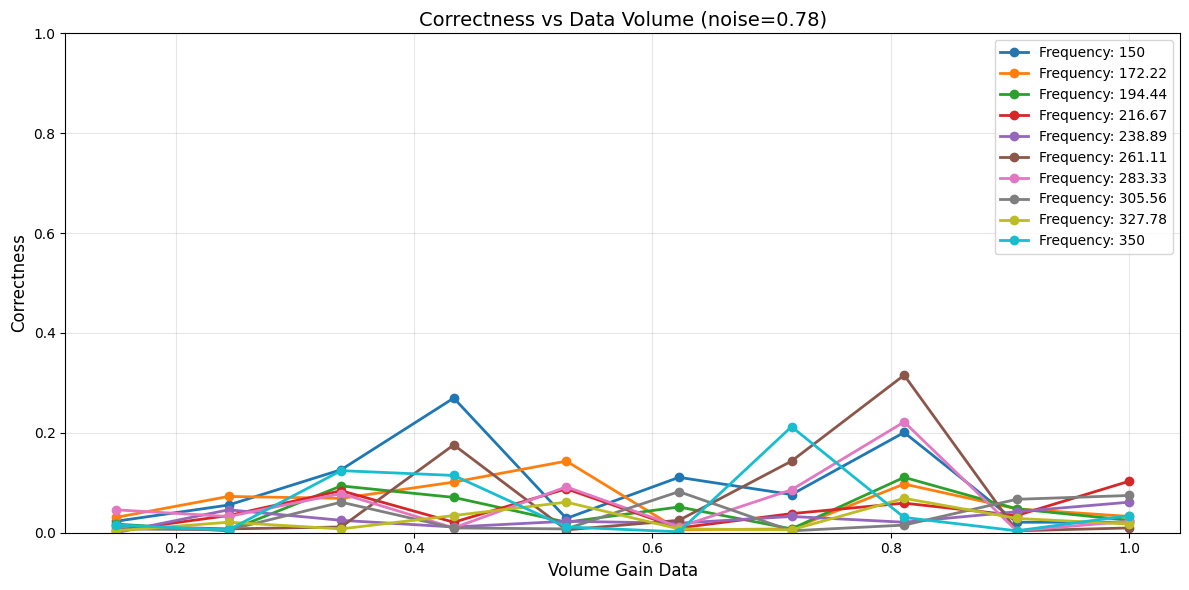

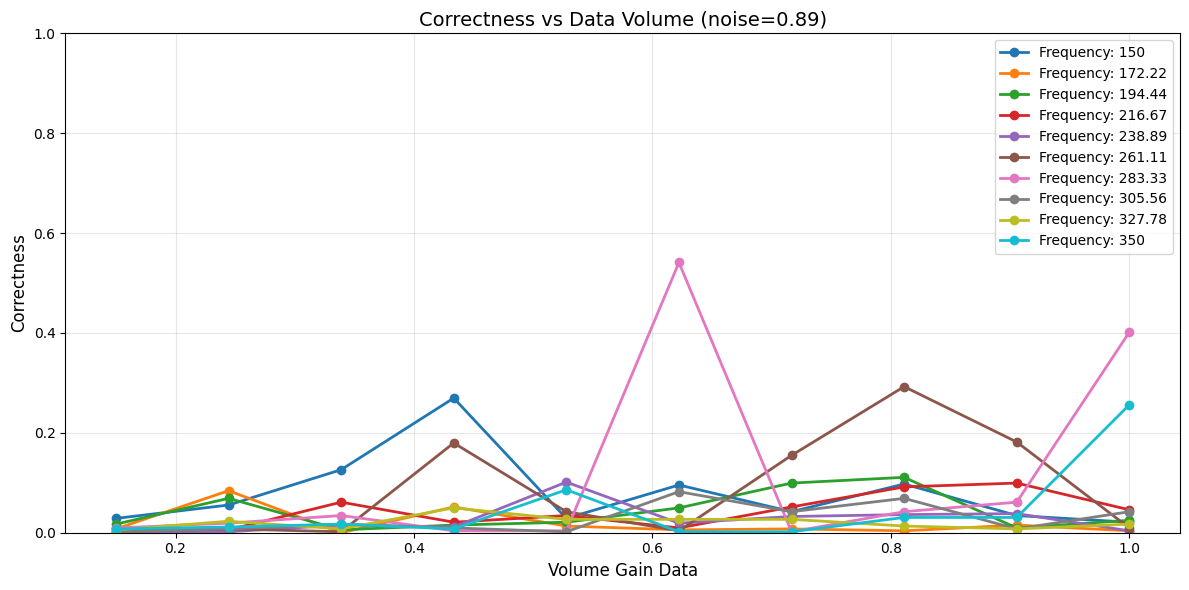

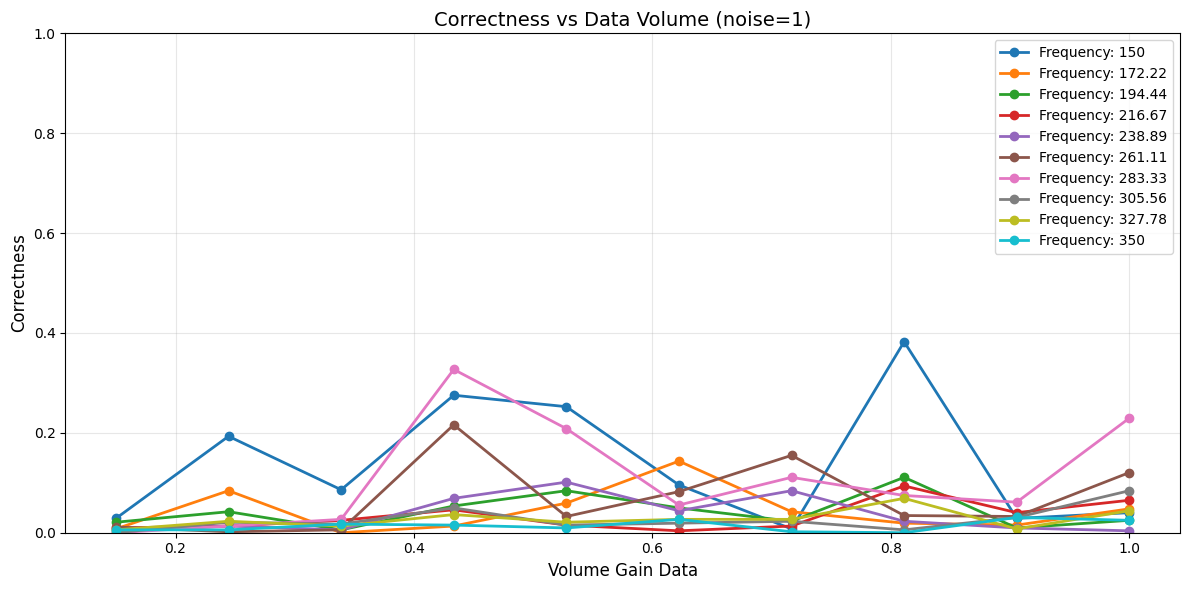

In [5]:
plot_correctness_vs_volume_gain_data(df)